In [1]:
import torch
from components.datasets import load_dataset
from components.models import init_mf_params, create_anfis_model
from components.trainer import train_model
import numpy as np

# Config
config = {
    "dataset": "thyroid", # options: mackey-glass, circles, spiral, moons, swiss-roll, iris, digits, cryotherapy, pima, haberman, immunotherapy, thyroid
    "mf_type": "advanced", # options: simple, advanced
    "mf_init": "random_uniform", # options: fcm, random_uniform
    "K": 2,
    "s_mode": "alpha_beta",
    "n_epochs": 1000,
    "lr": 0.001,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42,
}

# 1) Load dataset
X_train, X_test, y_train, y_test, task_type, n_outputs = load_dataset(config["dataset"])

# 2) Initialize MF
centers_init, spreads_init = init_mf_params(
    X_train, K=config["K"], method=config["mf_init"], scale=1.0, seed=config["seed"]
)

# 3) Create model
model = create_anfis_model(
    config["mf_type"], centers_init, spreads_init, n_outputs=n_outputs, s_mode=config["s_mode"]
).to(config["device"])



/home/nazanin/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


task_type: classification
n_outputs: 3
y unique: [0 1 2]
epoch    1 | train_loss=248.519905 | val_loss=254.738510, acc=0.7674
Early stopping at epoch 55 (best val_loss=254.738495)

Final Results:
Mode: alpha_beta
Train: accuracy rate 0.140 (24/171) | error 0.860 (147)
Test: accuracy rate 0.140 (6/43) | error 0.860 (37)

Per-rule, per-feature MF contributions and raw participation:
Rule 0, Feature 0: Raw weight -> Gaussian=0.4590, Sigmoid=0.5410
Rule 0, Feature 1: Raw weight -> Gaussian=0.4590, Sigmoid=0.5410
Rule 0, Feature 2: Raw weight -> Gaussian=0.4590, Sigmoid=0.5410
Rule 0, Feature 3: Raw weight -> Gaussian=0.4653, Sigmoid=0.5347
Rule 0, Feature 4: Raw weight -> Gaussian=0.4646, Sigmoid=0.5354
Rule 1, Feature 0: Raw weight -> Gaussian=0.4534, Sigmoid=0.5466
Rule 1, Feature 1: Raw weight -> Gaussian=0.4655, Sigmoid=0.5345
Rule 1, Feature 2: Raw weight -> Gaussian=0.4534, Sigmoid=0.5466
Rule 1, Feature 3: Raw weight -> Gaussian=0.4534, Sigmoid=0.5466
Rule 1, Feature 4: Raw weight -

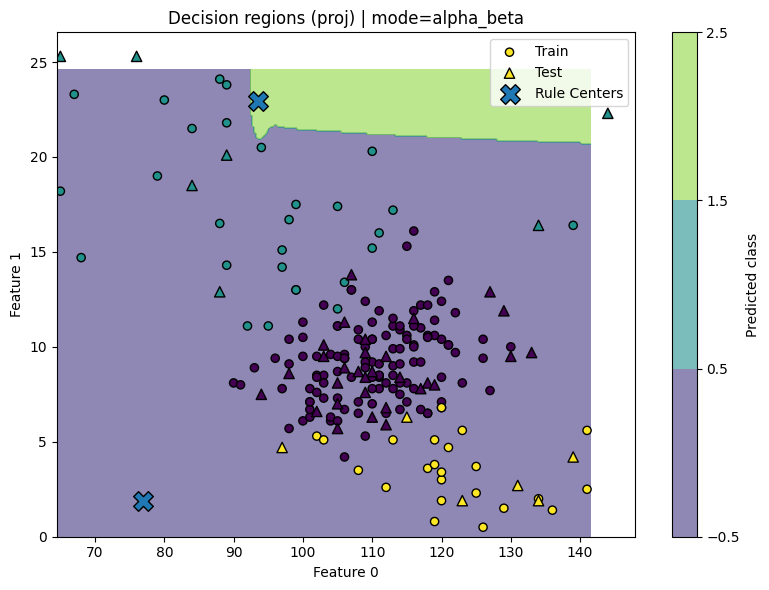

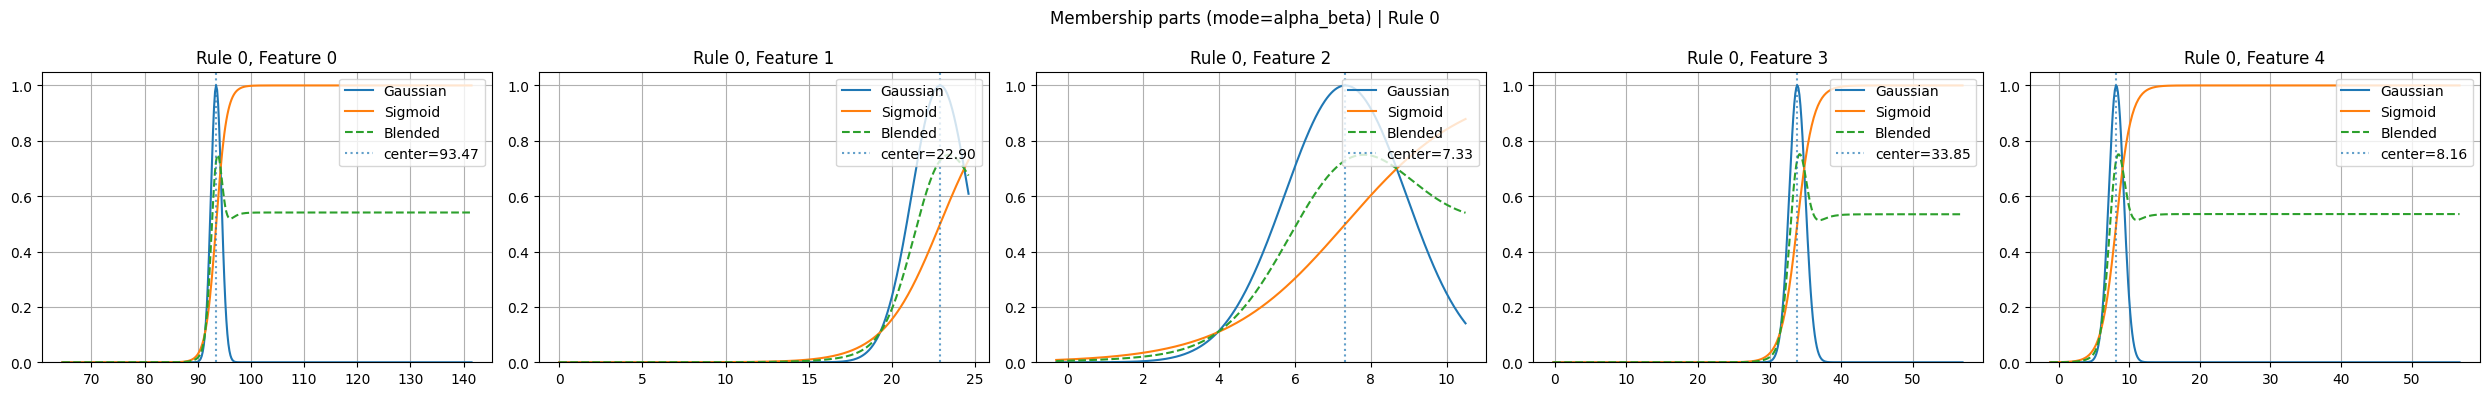

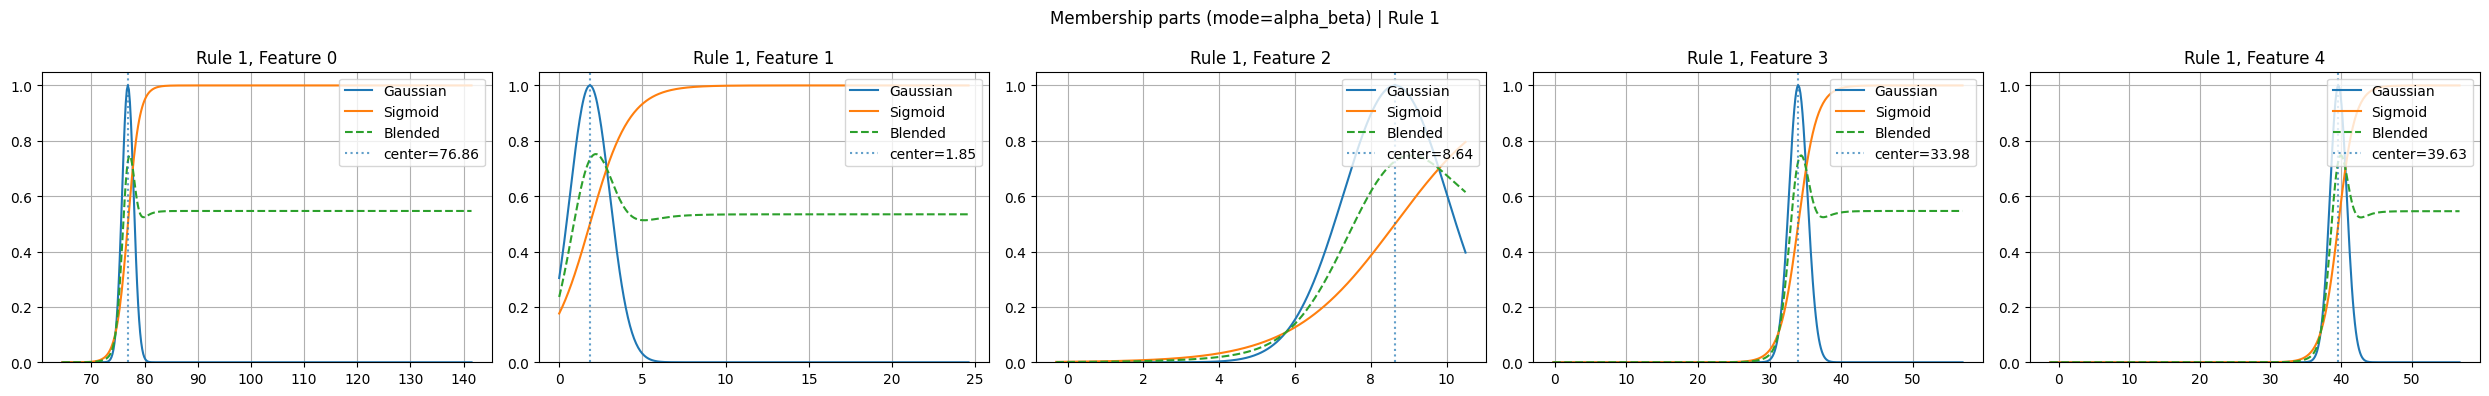

In [2]:
from components.utils import evaluate_anfis_model

print("task_type:", task_type)
print("n_outputs:", n_outputs)
print("y unique:", np.unique(y_train))


# 4) Train
model = train_model(
    model,
    X_train, y_train,
    X_test, y_test,
    task_type=task_type,
    n_outputs=n_outputs,
    n_epochs=config["n_epochs"],
    lr=config["lr"],
    device=config["device"],
)


# 5) Evaluate and plot results
evaluate_anfis_model(
    model, X_train, y_train, X_test, y_test, 
    device=config["device"], 
    s_mode_choice=config["s_mode"], 
    centers_init=centers_init,
    dataset_name=config["dataset"] 
)